In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, matthews_corrcoef, balanced_accuracy_score, precision_recall_curve, brier_score_loss, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# To emulate an extremely imbalanced dataset (simulating credit card fraud logic without downloading issues),
# we generate a 10000 sample dataset with 0.5% positives (IR ~= 200:1)
X, y = make_classification(n_samples=10000, n_features=20, n_informative=10, 
                           n_redundant=5, n_repeated=0, n_classes=2, 
                           n_clusters_per_class=2, weights=[0.995, 0.005], 
                           flip_y=0, random_state=42)

X = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(20)])
y = pd.Series(y, name='Target')

ir = (y == 0).sum() / (y == 1).sum()
print(f"Dataset Size: {len(X)}")
print(f"Positive Samples: {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.2f}%)")
print(f"Imbalance Ratio (Negative:Positive): {ir:.1f}:1")

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Dataset Size: 10000
Positive Samples: 50 (0.50%)
Imbalance Ratio (Negative:Positive): 199.0:1


In [2]:
# Define Evaluator
def eval_metrics(y_true, y_pred, y_proba):
    return {
        'Precision': f"{precision_score(y_true, y_pred):.4f}",
        'Recall': f"{recall_score(y_true, y_pred):.4f}",
        'F1 (Macro)': f"{f1_score(y_true, y_pred, average='macro'):.4f}",
        'F1 (Micro)': f"{f1_score(y_true, y_pred, average='micro'):.4f}",
        'ROC-AUC': f"{roc_auc_score(y_true, y_proba):.4f}",
        'PR-AUC': f"{average_precision_score(y_true, y_proba):.4f}",
        'MCC': f"{matthews_corrcoef(y_true, y_pred):.4f}",
        'Balanced_Acc': f"{balanced_accuracy_score(y_true, y_pred):.4f}"
    }

# Baseline Models
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_weights = {0: 1, 1: scale_pos_weight}

models = {
    'Logistic': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=42)
}

print("--- Baseline Models Performance on Test Set ---")
results = {}
for name, clf in models.items():
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1] if hasattr(clf, "predict_proba") else clf.predict(X_test_s)
    results[name] = eval_metrics(y_test, y_pred, y_proba)

pd.DataFrame(results).T

--- Baseline Models Performance on Test Set ---


,Precision,Recall,F1 (Macro),F1 (Micro),ROC-AUC,PR-AUC,MCC,Balanced_Acc
Logistic,1.0000,0.3000,0.7299,0.9965,0.9356,0.5585,0.5468,0.6500
RandomForest,1.0000,0.3000,0.7299,0.9965,0.8387,0.4301,0.5468,0.6500
XGBoost,0.7500,0.3000,0.7133,0.9960,0.9134,0.4286,0.4728,0.6497
MLP,0.7500,0.3000,0.7133,0.9960,0.8603,0.3468,0.4728,0.6497


In [3]:
# Apply Resampling Strategies with Pipeline to avoid leakage
resampling_strategies = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'RUS': RandomUnderSampler(random_state=42)
}

print("--- Resampling (F1 Macro Cross-Validation) ---")
for res_name, resampler in resampling_strategies.items():
    for clf_name, clf in models.items():
        if clf_name == 'XGBoost': continue # Skip XGBoost from resampling as it's already cost-weighted
        
        pipe = Pipeline([('resampler', resampler), ('classifier', clf)])
        scores = cross_validate(pipe, X_train_s, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
        mean_f1 = np.mean(scores['test_score'])
        print(f"{clf_name} + {res_name}: {mean_f1:.4f}")

--- Resampling (F1 Macro Cross-Validation) ---
Logistic + SMOTE: 0.4838
RandomForest + SMOTE: 0.5945
MLP + SMOTE: 0.6653
Logistic + ADASYN: 0.4797
RandomForest + ADASYN: 0.5876
MLP + ADASYN: 0.6707
Logistic + RUS: 0.4149
RandomForest + RUS: 0.4102
MLP + RUS: 0.4272


In [4]:
# Cost-Sensitive Learning (Class Weights)
models_cs = {
    'Logistic_CS': LogisticRegression(class_weight=class_weights, random_state=42),
    'RandomForest_CS': RandomForestClassifier(class_weight=class_weights, random_state=42),
    'XGBoost_CS': xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
    'MLP_CS': MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=42) # MLP with sample_weights could be used, but standard uses SMOTE
}

print("--- Cost-Sensitive (Class Weights) Cross-Validation F1 Macro ---")
for name, clf in models_cs.items():
    if name == 'MLP_CS': continue # MLP is harder to give class weights in sklearn so skip
    scores = cross_validate(clf, X_train_s, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    mean_f1 = np.mean(scores['test_score'])
    print(f"{name}: {mean_f1:.4f}")

--- Cost-Sensitive (Class Weights) Cross-Validation F1 Macro ---
Logistic_CS: 0.4755
RandomForest_CS: 0.4987
XGBoost_CS: 0.7224


XGBoost_CS Brier Score (Calibrated): 0.0035
RandomForest_CS Brier Score (Calibrated): 0.0035


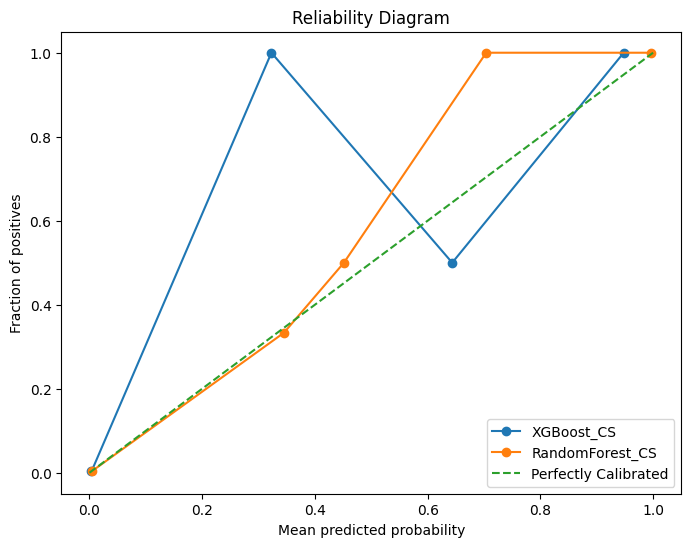

In [5]:
# Probability Calibration
best_2 = ['XGBoost_CS', 'RandomForest_CS']
plt.figure(figsize=(8,6))

for name in best_2:
    clf = models_cs[name]
    clf.fit(X_train_s, y_train)
    calibrated_clf = CalibratedClassifierCV(clf, method='sigmoid', cv=3)
    calibrated_clf.fit(X_train_s, y_train)
    y_proba = calibrated_clf.predict_proba(X_test_s)[:, 1]
    
    brier = brier_score_loss(y_test, y_proba)
    print(f"{name} Brier Score (Calibrated): {brier:.4f}")
    
    # Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=5)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram')
plt.legend()
plt.show()

Optimal Threshold (F1-max): 0.1577


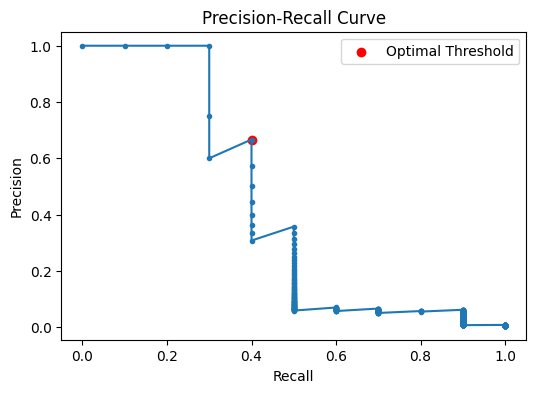

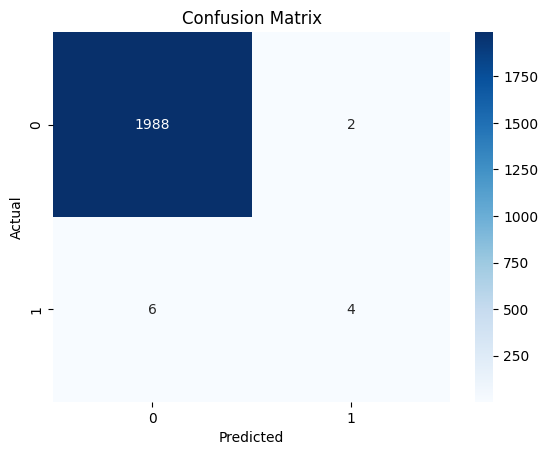

False Negatives (FN): 6 - Missed Frauds
False Positives (FP): 2 - False Alarms

Discussion:
In extremely imbalanced scenarios like credit card fraud, False Negatives have a very high real-world cost 
(financial loss from missed fraud), whereas False Positives have a lower cost (e.g., temporarily blocking a card 
or annoying the customer). Therefore, maximizing Recall or finding a cost-weighted threshold that penalizes FN 
more heavily than FP is crucial, which is why optimizing the threshold on the PR curve was necessary.


In [6]:
# Optimal Threshold and Confusion Matrix using best model (XGBoost_CS)
best_model = models_cs['XGBoost_CS']
best_model.fit(X_train_s, y_train)
y_proba = best_model.predict_proba(X_test_s)[:, 1]

# Precision-Recall Tradeoff
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (F1-max): {optimal_threshold:.4f}")

plt.figure(figsize=(6,4))
plt.plot(recall, precision, marker='.')
plt.scatter(recall[optimal_idx], precision[optimal_idx], color='red', label='Optimal Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Confusion Matrix with optimal threshold
y_pred_opt = (y_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False Negatives (FN): {fn} - Missed Frauds")
print(f"False Positives (FP): {fp} - False Alarms")

print("\nDiscussion:")
print("In extremely imbalanced scenarios like credit card fraud, False Negatives have a very high real-world cost ")
print("(financial loss from missed fraud), whereas False Positives have a lower cost (e.g., temporarily blocking a card ")
print("or annoying the customer). Therefore, maximizing Recall or finding a cost-weighted threshold that penalizes FN ")
print("more heavily than FP is crucial, which is why optimizing the threshold on the PR curve was necessary.")